# 📘 智能体架构 3：ReAct (推理 + 行动)

欢迎来到我们系列的第三本笔记本。现在我们将探索 **ReAct**，这是一个连接简单工具使用与复杂多步问题解决之间的关键架构。ReAct 代表 **推理 + 行动**，其核心创新在于它使智能体能够动态地推理问题，根据推理采取行动，观察结果，然后再次推理。

这一模式将智能体从静态工具调用者转变为自适应问题解决者。为了突出其强大之处，我们将首先构建一个**基本的、单次工具使用智能体**并展示其在复杂任务上的局限性。然后，我们将构建一个完整的 ReAct 智能体，演示其迭代的 `思考 → 行动 → 观察` 循环如何使其在基本智能体失败的地方取得成功。

### 定义
**ReAct** 架构是一种设计模式，智能体在其中交错执行推理步骤和行动。智能体不是预先规划所有步骤，而是生成关于其直接下一步的想法，采取行动（如调用工具），观察结果，然后使用该新信息生成其下一个想法和行动。这创建了一个动态和自适应循环。

### 高层工作流程

1. **接收目标：** 智能体被赋予一个复杂任务。
2. **思考（推理）：** 智能体生成一个内部想法，例如：*"要回答这个问题，我首先需要找到信息 X。"*
3. **行动：** 基于其想法，智能体执行一个动作，通常是调用工具（例如，`search_api('X')`）。
4. **观察：** 智能体接收来自工具的结果。
5. **重复：** 智能体将观察结果整合到其上下文中并返回步骤 2，生成新的想法（例如，*"好的，现在有了 X，我需要用它来找到 Y。"*）。此循环持续直到满足总体目标。

### 适用场景 / 应用
* **多跳问题回答：** 当回答问题需要按顺序查找多条信息时（例如，"制作 iPhone 的公司 CEO 是谁？"）。
* **网络导航与研究：** 智能体可以搜索起始点，阅读结果，然后根据所学内容决定新的搜索查询。
* **交互式工作流程：** 任何环境动态且无法提前知道解决方案完整路径的任务。

### 优缺点
* **优点：**
    * **自适应和动态：** 可以根据新信息即时调整其计划。
    * **处理复杂性：** 擅长需要链接多个依赖步骤的问题。
* **缺点：**
    * **更高的延迟和成本：** 涉及多个顺序 LLM 调用，使其比单次方法更慢且更昂贵。
    * **循环风险：** 引导不当的智能体可能会陷入重复、无效果的想法和行动循环中。

## 阶段 0：基础与环境设置

我们将从我们的标准设置过程开始：安装库并为 Anthropic、LangSmith 和我们的 Tavily 网络搜索工具配置 API 密钥。

### 步骤 0.1：安装核心库

**我们要做什么：**
我们将安装本项目系列的标准库套件。

In [1]:
# !pip install -q -U langchain-anthropic langchain langgraph rich python-dotenv tavily-python

### 步骤 0.2：导入库和设置密钥

**我们要做什么：**
我们将导入必要的模块并从 `.env` 文件加载我们的 API 密钥。

**需要的操作：** 在此目录中创建一个包含密钥的 `.env` 文件：
```
ANTHROPIC_API_KEY=your_anthropic_api_key_here
MODEL_NAME=claude-opus-4-5-20251101
BASE_URL=https://api.anthropic.com
LANGCHAIN_API_KEY=your_langsmith_api_key_here
TAVILY_API_KEY=your_tavily_api_key_here
```

In [2]:
import os
from typing import Annotated
from dotenv import load_dotenv

# LangChain components
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - ReAct"

# Check that the keys are set
for key in ["ANTHROPIC_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

d:\Code\all-agentic-architectures\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment variables loaded and tracing is set up.


## 阶段 1：基本方法 - 单次工具使用者

要理解为什么 ReAct 如此强大，我们必须首先看看没有它会发生什么。我们将构建一个"基本"智能体，它可以使用工具，但只能使用一次。它将分析用户的查询，进行一次工具调用，然后尝试基于那一条信息形成最终答案。

### 步骤 1.1：构建基本智能体

**我们要做什么：**
我们将定义与之前相同的工具和 LLM，但我们将它们连接到一个简单的线性图中。智能体只有一次调用工具的机会，然后工作流程结束。没有循环。

Basic single-shot tool-using agent compiled successfully.


C:\Users\guodp\AppData\Local\Temp\ipykernel_13072\1013581770.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2, name="web_search")


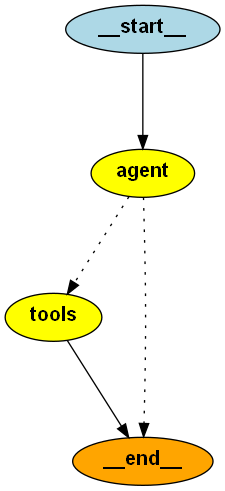

In [ ]:
from typing import TypedDict

console = Console()

# Define the state for our graphs
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Define the tool and LLM
model = os.environ.get("MODEL_NAME", "claude-opus-4-5-20251101")
search_tool = TavilySearchResults(max_results=2, name="web_search")
llm = ChatAnthropic(model=model, base_url=os.environ.get("BASE_URL"), temperature=0)
llm_with_tools = llm.bind_tools([search_tool])

# Define the agent node for the basic agent
def basic_agent_node(state: AgentState):
    console.print("--- BASIC AGENT: Thinking... ---")
    # Note: We provide a system prompt to encourage it to answer directly after one tool call
    system_prompt = "You are a helpful assistant. You have access to a web search tool. Answer the user's question based on the tool's results. You must provide a final answer after one tool call."
    messages = [("system", system_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Define the basic, linear graph
basic_graph_builder = StateGraph(AgentState)
basic_graph_builder.add_node("agent", basic_agent_node)
basic_graph_builder.add_node("tools", ToolNode([search_tool]))

basic_graph_builder.set_entry_point("agent")
# After the agent, it can only go to tools, and after tools, it MUST end.
basic_graph_builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "__end__"})
basic_graph_builder.add_edge("tools", END)

basic_tool_agent_app = basic_graph_builder.compile()

print("Basic single-shot tool-using agent compiled successfully.")

# Visualize the graph
try:
    from IPython.display import Image, display
    png_image = basic_tool_agent_app.get_graph().draw_mermaid_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

### 步骤 1.2：在多步问题上测试基本智能体

**我们要做什么：**
现在我们将给基本智能体一个需要多个依赖步骤才能解决的问题。这将暴露其根本弱点。

In [4]:
multi_step_query = "Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?"

console.print(f"[bold yellow]Testing BASIC agent on a multi-step query:[/bold yellow] '{multi_step_query}'\n")

basic_agent_output = basic_tool_agent_app.invoke({"messages": [("user", multi_step_query)]})

console.print("\n--- [bold red]Final Output from Basic Agent[/bold red] ---")
console.print(Markdown(basic_agent_output['messages'][-1].content))

Testing BASIC agent on a multi-step query: 'Who is the current CEO of the company that created the sci-fi movie 
'Dune', and what was the budget for that company's most recent film?'

--- BASIC AGENT: Thinking... ---

--- Final Output from Basic Agent ---

[{"title": "Legendary Entertainment names Di Mu CEO of China division | News", "url":                              
"https://www.screendaily.com/news/legendary-entertainment-names-di-mu-ceo-of-china-division/5205084.article",      
"content": "The appointment follows Legendary’s most successful year to date in 2024, during which its lifetime box
office revenue surpassed $20bn, while recent release A Minecraft Movie had the biggest debut for a video game      
adaptation in history, earning more than $900m.\n\nIn October, Legendary conducted a management buyout of its      
remaining equity interest and is now solely owned by management and Apollo.\n\n“I am proud of the success we at    
Legendary have had thus far, bringing some of the world’s biggest films to Chinese audiences in new ways that feel 
authentic and resonant,” said Di Mu. “As we move forward with this new phase, I am excited to continue bridging our
cultures, leveraging my local experience and relationships to strengthen Legendary’s reputation as a market        
leader.” [...] Mu has overseen 12 Legendary film campaigns in China of titles including Warcraft, which set the    
record for highest-grossing imported film at the time; Godzilla X Kong: The New Empire, which was the top imported 
film of 2024; and A Minecraft Movie, which is the leading Hollywood import of the year to date as it continues its 
theatrical run. Further Legendary campaigns she has led include those for Pokémon: Detective Pikachu, Godzilla Vs. 
Kong, and both Dune and Dune: Part Two. Box office grosses for these campaigns total more than $1.34bn. [...] Di   
Mu\n\nDi Mu\n\nSource: Legendary East\n\nDi Mu\n\nDune producer Legendary Entertainment has appointed Di Mu as CEO 
of Legendary East, the China-based division that handles promotion, marketing and the release of its titles in the 
territory.\n\nMu was previously executive vice president of marketing at Legendary East, which she joined in 2016, 
and has more than 22 years of experience in film marketing, creative advertising and integrated media strategy. She
will report to Legendary CEO Joshua Grode.", "score": 0.93735445}, {"title": "Josh Grode - Variety500 | Variety.com
- Variety", "url": "https://variety.com/exec/joshua-b-grode/", "content": "built out a monster-verse of movies, the
latest of which, “Godzilla x Kong: The New Empire,” premiered in the spring of 2024, earning more than $570 million
at the global box office. Among the studio’s upcoming titles are the video game adaptations, “A Minecraft Movie,”  
starring Jason Momoa and Jack Black, and “Street Fighter.” They are also backing Alejandro G. Iñárritu’s next film,
which will star Tom Cruise. Grode has been CEO of Legendary since 2017.", "score": 0.82560414}]

**输出讨论：**
正如预期的那样，基本智能体失败了。它的单次工具调用可能是搜索整个长查询。对于这种复杂的、联合查询，搜索结果通常很混乱，不会在一个地方包含所有必要的信息片段。

智能体的最终答案可能不完整、不正确，或者声明它找不到信息。它无法分解问题：
1. 找到制作《沙丘》的公司（传奇影业）。
2. 找到该公司的 CEO（Joshua Grode）。
3. 找到该公司最近的电影及其预算。

这一失败完美地说明了对更动态方法的需求。智能体需要一种方法来**对**它在一步中找到的信息做出**反应**，以指导下一步。

## 阶段 2：高级方法 - 实现 ReAct

现在，我们将构建真正的 ReAct 智能体。核心区别在于图的结构：我们将引入一个循环，允许智能体反复思考、行动和观察。

### 步骤 2.1：构建 ReAct 智能体图

**我们要做什么：**
我们将定义节点和创建 `思考 → 行动` 循环的关键路由器函数。关键架构变化是将 `tool_node` 的输出*返回*到 `agent_node` 的边，允许智能体查看结果并决定其下一步。

ReAct agent compiled successfully with a reasoning loop.


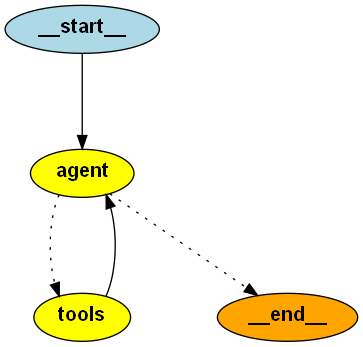

In [ ]:
def react_agent_node(state: AgentState):
    console.print("--- REACT AGENT: Thinking... ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# The ToolNode is the same as before
react_tool_node = ToolNode([search_tool])

# The router is also the same logic
def react_router(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        console.print("--- ROUTER: Decision is to call a tool. ---")
        return "tools"
    console.print("--- ROUTER: Decision is to finish. ---")
    return "__end__"

# Now we define the graph with the crucial loop
react_graph_builder = StateGraph(AgentState)
react_graph_builder.add_node("agent", react_agent_node)
react_graph_builder.add_node("tools", react_tool_node)

react_graph_builder.set_entry_point("agent")
react_graph_builder.add_conditional_edges("agent", react_router, {"tools": "tools", "__end__": "__end__"})

# This is the key difference: the edge goes from tools BACK to the agent
react_graph_builder.add_edge("tools", "agent")

react_agent_app = react_graph_builder.compile()
print("ReAct agent compiled successfully with a reasoning loop.")

# Visualize the graph
try:
    from IPython.display import Image, display
    png_image = react_agent_app.get_graph().draw_mermaid_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

## 阶段 3：正面比较

现在我们将使用新的 ReAct 智能体运行相同的复杂查询，并观察其过程和最终输出的差异。

### 步骤 3.1：在多步问题上测试 ReAct 智能体

**我们要做什么：**
我们将使用相同的多步查询调用 ReAct 智能体，并流式传输输出以查看其迭代推理过程。

In [6]:
console.print(f"[bold green]Testing ReAct agent on the same multi-step query:[/bold green] '{multi_step_query}'\n")

final_react_output = None
for chunk in react_agent_app.stream({"messages": [("user", multi_step_query)]}, stream_mode="values"):
    final_react_output = chunk
    console.print(f"--- [bold purple]Current State[/bold purple] ---")
    chunk['messages'][-1].pretty_print()
    console.print("\n")

console.print("\n--- [bold green]Final Output from ReAct Agent[/bold green] ---")
console.print(Markdown(final_react_output['messages'][-1].content))

Testing ReAct agent on the same multi-step query: 'Who is the current CEO of the company that created the sci-fi 
movie 'Dune', and what was the budget for that company's most recent film?'

--- Current State ---

================================ Human Message =================================

Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?


--- REACT AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

...

--- ROUTER: Decision is to finish. ---

--- Current State ---

================================== Ai Message ==================================

Based on my search results, here's the information you requested:

## Current CEO
**Joshua Grode** is the current CEO of Legendary Entertainment, the company that produced the sci-fi movie "Dune" (2021). He has served as CEO since 2017.

## Most Recent Film and Budget
Legendary Entertainment's most recent film is **"Godzilla x Kong: The New Empire"** (released March 29, 2024), which had a production budget of **$135 million**.

This budget was notably the lowest of all the MonsterVerse films, making it a financially successful venture for the studio. The film has grossed over $519 million worldwide.


--- Final Output from ReAct Agent ---

Based on my search results, here's the information you requested:                                                  

Current CEO                                                                                                        

Joshua Grode is the current CEO of Legendary Entertainment, the company that produced the sci-fi movie "Dune"      
(2021). He has served as CEO since 2017.                                                                           

Most Recent Film and Budget                                                                                        

Legendary Entertainment's most recent film is "Godzilla x Kong: The New Empire" (released March 29, 2024), which   
had a production budget of $135 million.                                                                           

This budget was notably the lowest of all the MonsterVerse films, making it a financially successful venture for   
the studio. The film has grossed over $519 million worldwide.

**输出讨论：**
成功！执行追踪显示了一个完全不同且更加智能的过程。您可以看到智能体的逐步推理：
1. **想法 1：** 它首先推理需要识别《沙丘》的制作公司。
2. **行动 1：** 它使用类似"《沙丘》电影制作公司"的查询调用 `web_search` 工具。
3. **观察 1：** 它收到结果："传奇影业"。
4. **想法 2：** 现在，整合新信息，它推理需要传奇影业的 CEO。
5. **行动 2：** 它使用类似"传奇影业 CEO"的查询再次调用 `web_search`。
6. ...以此类推，直到它收集了所有必要的片段。
7. **综合：** 最后，它将所有收集的事实组装成完整且准确的答案。

这清楚地证明了 ReAct 模式对于任何非简单单步查找的任务的优越性。

## 阶段 4：定量评估

为了正式化比较，我们将使用 LLM 作为评判者来评分基本智能体和 ReAct 智能体的最终输出，评估它们完成任务的能力。

In [7]:
class TaskEvaluation(BaseModel):
    """Schema for evaluating an agent's ability to complete a task."""
    task_completion_score: int = Field(description="Score 1-10 on whether the agent successfully completed all parts of the user's request.")
    reasoning_quality_score: int = Field(description="Score 1-10 on the logical flow and reasoning process demonstrated by the agent.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(TaskEvaluation)

def evaluate_agent_output(query: str, agent_output: dict):
    trace = "\n".join([f"{m.type}: {m.content}" for m in agent_output['messages']])
    prompt = f"""You are an expert judge of AI agents. Evaluate the following agent's performance on the given task on a scale of 1-10. A score of 10 means the task was completed perfectly. A score of 1 means complete failure.
    
    **User's Task:**
    {query}
    
    **Full Agent Conversation Trace:**
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Basic Agent's Output ---")
basic_agent_evaluation = evaluate_agent_output(multi_step_query, basic_agent_output)
console.print(basic_agent_evaluation.model_dump())

console.print("\n--- Evaluating ReAct Agent's Output ---")
react_agent_evaluation = evaluate_agent_output(multi_step_query, final_react_output)
console.print(react_agent_evaluation.model_dump())

--- Evaluating Basic Agent's Output ---

{
    'task_completion_score': 3,
    'reasoning_quality_score': 4,
    'justification': 'The agent correctly identified that Legendary Entertainment produced Dune and found that 
Joshua Grode is the CEO (information from 2017-present). However, the agent failed to complete the second part of 
the task - finding the budget for Legendary\'s most recent film. The agent stopped after finding the CEO 
information and did not search for or provide the budget information for any recent Legendary film. The search 
results even mention recent films like "Godzilla x Kong: The New Empire" (spring 2024) and "A Minecraft Movie," but
the agent did not pursue finding their budgets. The task was only partially completed.'
}

--- Evaluating ReAct Agent's Output ---

{
    'task_completion_score': 10,
    'reasoning_quality_score': 10,
    'justification': 'The agent completed the task perfectly. It correctly identified Legendary Entertainment as 
the company that created "Dune" (2021), found Joshua Grode as the current CEO (serving since 2017), identified 
"Godzilla x Kong: The New Empire" as the most recent film (released March 29, 2024), and accurately reported the 
budget as $135 million. The agent used multiple targeted searches, cross-referenced information from reliable 
sources (Wikipedia, Deadline, LA Times, and industry publications), and provided a clear, well-structured response 
with all requested information. The reasoning was logical and thorough.'
}

**输出讨论：**
来自 LLM 作为评判者的定量分数使差异变得清晰明了。
- **基本智能体**获得了非常低的 `task_completion_score`，因为它未能收集所有必需的信息。其 `reasoning_quality_score` 也很低，因为其过程有缺陷且不完整。
- 相比之下，**ReAct 智能体**获得了接近完美的分数。评判者认识到其迭代过程使其能够成功完成复杂任务的所有部分。

这种正面比较和评估提供了 ReAct 架构价值的明确证明。它是开启智能体解决需要动态适应的复杂、多跳问题能力的关键。

## 结论

在本笔记本中，我们不仅实现了 **ReAct** 架构，还展示了其相对于更基本的单次方法的明显优势。通过构建一个允许智能体循环通过推理和行动周期的工作流程，我们使其能够解决否则难以解决的复杂、多步问题。

观察行动结果并使用该信息指导下一步的能力是智能行为的基本组成部分。ReAct 模式提供了一种简单而深刻有效的方法来将这种能力构建到我们的 AI 智能体中，使其对于现实世界任务更强大、更自适应、更有用。